In [1]:
!pip install nltk datasets wordcloud seaborn matplotlib pandas

In [3]:
import pandas as pd
import numpy as np
import nltk
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from nltk.sentiment import SentimentIntensityAnalyzer
from wordcloud import WordCloud

In [4]:
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


True

In [9]:
dataset = load_dataset("mteb/amazon_polarity",split="test[:500]")
df = dataset.to_pandas()
df.head()

README.md:   0%|          | 0.00/6.76k [00:00<?, ?B/s]

data/train-00000-of-00004.parquet: reconstructing file:   0%|          |  0.00B /  255MB            

data/train-00000-of-00004.parquet: downloading bytes:           |  0.00B            

data/train-00001-of-00004.parquet: reconstructing file:   0%|          |  0.00B /  254MB            

data/train-00001-of-00004.parquet: downloading bytes:           |  0.00B            

...

data/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  115MB            

data/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/3599994 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/400000 [00:00<?, ? examples/s]

,label,text,label_text
0,1,Great CD\n\nMy lovely Pat has one of the GREAT...,positive
1,1,One of the best game music soundtracks - for a...,positive
2,0,Batteries died within a year ...\n\nI bought t...,negative
3,1,"works fine, but Maha Energy is better\n\nCheck...",positive
4,1,Great for the non-audiophile\n\nReviewed quite...,positive


In [10]:
print("Number of reviews:",len(df))
print("\nColumn Name:")
print(df.columns)
print("\nDataset information:")
print(df.info())

Number of reviews: 500

Column Name:
Index(['label', 'text', 'label_text'], dtype='object')

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   label       500 non-null    int64 
 1   text        500 non-null    object
 2   label_text  500 non-null    object
dtypes: int64(1), object(2)
memory usage: 11.8+ KB
None


In [16]:
df = df[['text', 'label']].copy()
df.rename(columns={'text':'review'},inplace=True)
df.head()

KeyError: "['text'] not in index"

In [14]:
sia=SentimentIntensityAnalyzer()

In [17]:
df['sentiment_score']=df['review'].apply(lambda text:sia.polarity_scores(str(text))['compound'])
df.head()

,review,label,sentiment_score
0,Great CD\n\nMy lovely Pat has one of the GREAT...,1,0.9569
1,One of the best game music soundtracks - for a...,1,0.8770
2,Batteries died within a year ...\n\nI bought t...,0,0.7297
3,"works fine, but Maha Energy is better\n\nCheck...",1,0.7845
4,Great for the non-audiophile\n\nReviewed quite...,1,0.8388


In [18]:
def classify_sentiment(score):
    if score >= 0.05:
        return 'Positive'
    elif score <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

        df['sentiment']=df['sentiment_score'].apply(classify_sentiment)
        df.head()

In [21]:
def classify_sentiment(score):
    if score >= 0.05:
        return 'Positive'
    elif score <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

df['sentiment']=df['sentiment_score'].apply(classify_sentiment)

print(df[['review',
          'sentiment_score',
          'sentiment']].head(10))

                                              review  sentiment_score sentiment
0  Great CD\n\nMy lovely Pat has one of the GREAT...           0.9569  Positive
1  One of the best game music soundtracks - for a...           0.8770  Positive
2  Batteries died within a year ...\n\nI bought t...           0.7297  Positive
3  works fine, but Maha Energy is better\n\nCheck...           0.7845  Positive
4  Great for the non-audiophile\n\nReviewed quite...           0.8388  Positive
5  DVD Player crapped out after one year\n\nI als...          -0.3506  Negative
6  Incorrect Disc\n\nI love the style of this, bu...          -0.0638  Negative
7  DVD menu select problems\n\nI cannot scroll th...           0.2329  Positive
8  Unique Weird Orientalia from the 1930's\n\nExo...           0.1280  Positive
9  Not an "ultimate guide"\n\nFirstly,I enjoyed t...           0.9633  Positive


In [22]:
sentiment_counts=df['sentiment'].value_counts()
print(sentiment_counts)

sentiment
Positive    340
Negative    151
Neutral       9
Name: count, dtype: int64


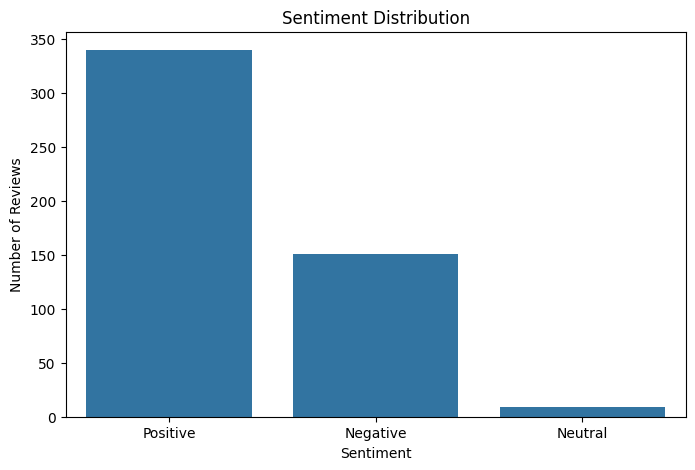

In [23]:
plt.figure(figsize=(8,5))
sns.countplot(data=df,x='sentiment')
plt.title('Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')
plt.show()

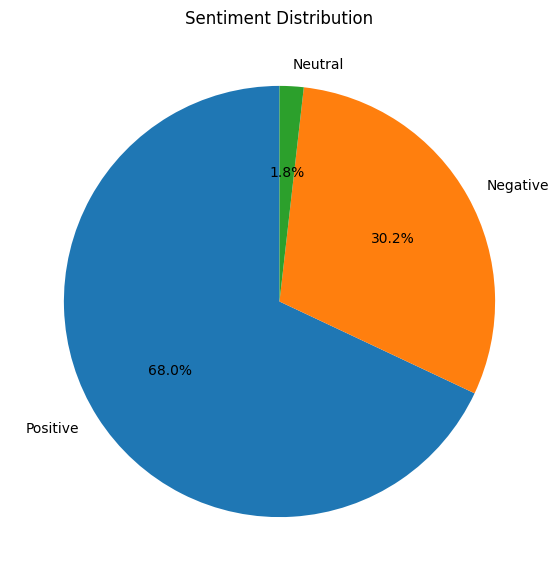

In [24]:
plt.figure(figsize=(7,7))
df['sentiment'].value_counts().plot(kind='pie',autopct='%1.1f%%',startangle=90)
plt.title('Sentiment Distribution')
plt.ylabel('')
plt.show()

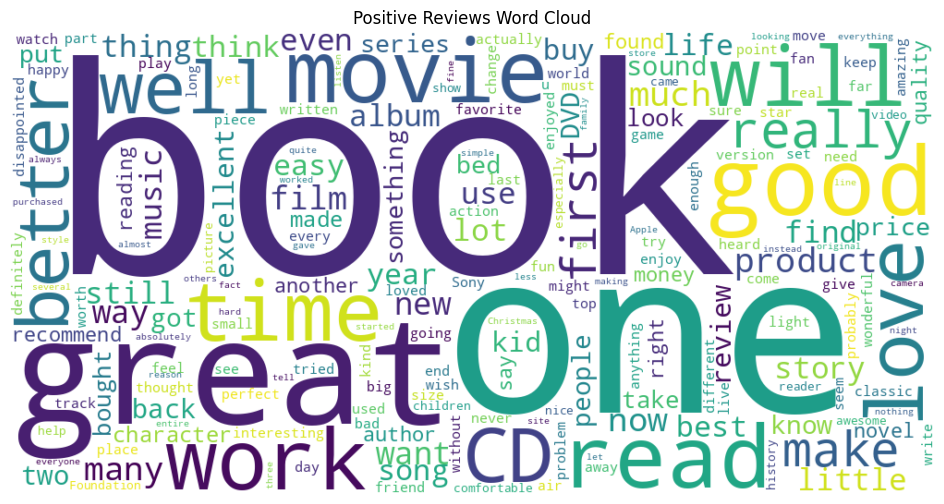

In [28]:
positive_text = " ".join(
    df[df['sentiment'] == 'Positive']['review'].astype(str)
)
wordcloud_positive = WordCloud(width=1000, height=500, background_color='white').generate(positive_text)
plt.figure(figsize=(12,6))
plt.imshow(wordcloud_positive, interpolation='bilinear')
plt.axis('off')
plt.title('Positive Reviews Word Cloud')
plt.show()

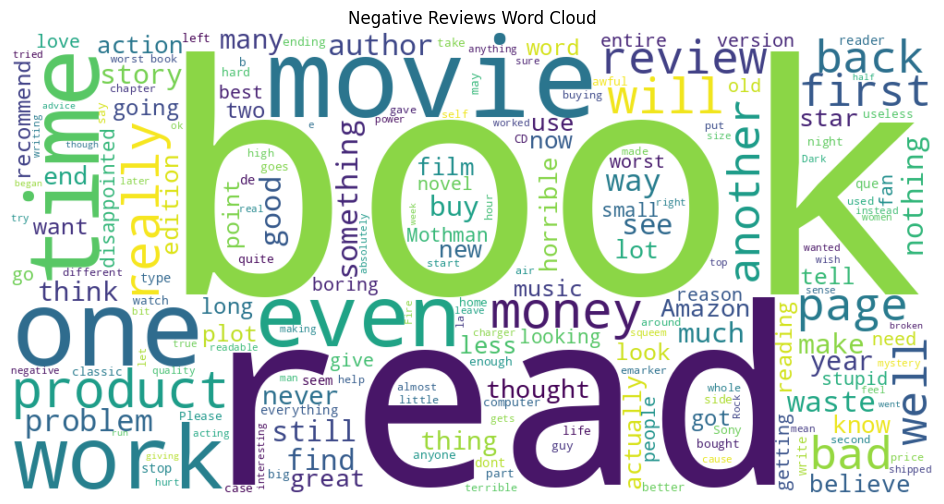

In [30]:
negative_text = " ".join(
    df[df['sentiment'] == 'Negative']['review'].astype(str))
wordcloud_negative = WordCloud(width=1000, height=500, background_color='white').generate(negative_text)
plt.figure(figsize=(12,6))
plt.imshow(wordcloud_negative, interpolation='bilinear')
plt.axis('off')
plt.title('Negative Reviews Word Cloud')
plt.show()

In [31]:
most_positive = df.loc[df['sentiment_score'].idxmax()]
print("Most Positive Review:")
print(most_positive['review'])
print("\nScore:")
print(most_positive['sentiment_score'])


Most Positive Review:
The Best Present Of All

My children are a little old (age-wise) for this, but we all still enjoy watching it around this time of year. This classic will never die out, as it will be enjoyed for many generations to come.Having always been a huge fan of Charlie Brown to begin with, this is, by far, my favorite Christmas special. I can remember seeing it for the first time like it was yesterday. Charles Shulzz did one amazing job with this classic. This short animated special shows children the true meaning of Christmas, and Linus' delightful explanation is timeless in its teaching.This classic is something that can be enjoyed by people of all ages, but especially by families with small children. This is just one great video that would make an excellent addition to anyone's collection.

Score:
0.9969


In [32]:
most_negative = df.loc[df['sentiment_score'].idxmin()]
print("Most Negative Review:")
print(most_negative['review'])
print("\nScore:")
print(most_negative['sentiment_score'])

Most Negative Review:
Avoid it.

The abridged version of this book would read as so:"Sin is inevitable. So make the best of bad situations. And oh by the way... women are strong."There ya go. Nuff said. I don't need to read obnoxiously long sentences lamenting on one sentiment for the entire 160 odd pages or so of this travesty. The entire book is just one big complaint. From the girl who commits adultery. She laments about it for the whole stinking book and puts up with some obnoxious kid the for whole thing as well. Painfully thick language, stupid storyline, quixotic style... everything that would piss off a recreational reader. Avoid it.

Score:
-0.986


In [33]:
df.to_csv('sentiment_analysis_results.csv',index=False)
print("File saved successfully!")

File saved successfully!


In [34]:
from google.colab import files
files.download('sentiment_analysis_results.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

SENTIMENT ANALYSIS
1. Loads amazon review data
2. Processes text using NLP
3. Calculates sentiment scores
4. Classifies reviews as positive/negative/netural
5. Displays sentiment distribution
6. Creates bar and pie charts
7. creates positive and negative word clouds
8. Finds most positive & negative reviews
9. Exports the final analysis to CSV